<a href="https://colab.research.google.com/github/KHLLS/HR_Analysis/blob/main/HRAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_profiling import ProfileReport
from google.colab import files
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('/content/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
profiling = ProfileReport(df,title='Report',explorative=True)
profiling.to_file('profiling.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 22.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   Department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


In [6]:
sns.set(style='whitegrid')

In [7]:
col_numeric = df.select_dtypes(include=np.number).columns
cat_numeric = df.select_dtypes(exclude=np.number).columns

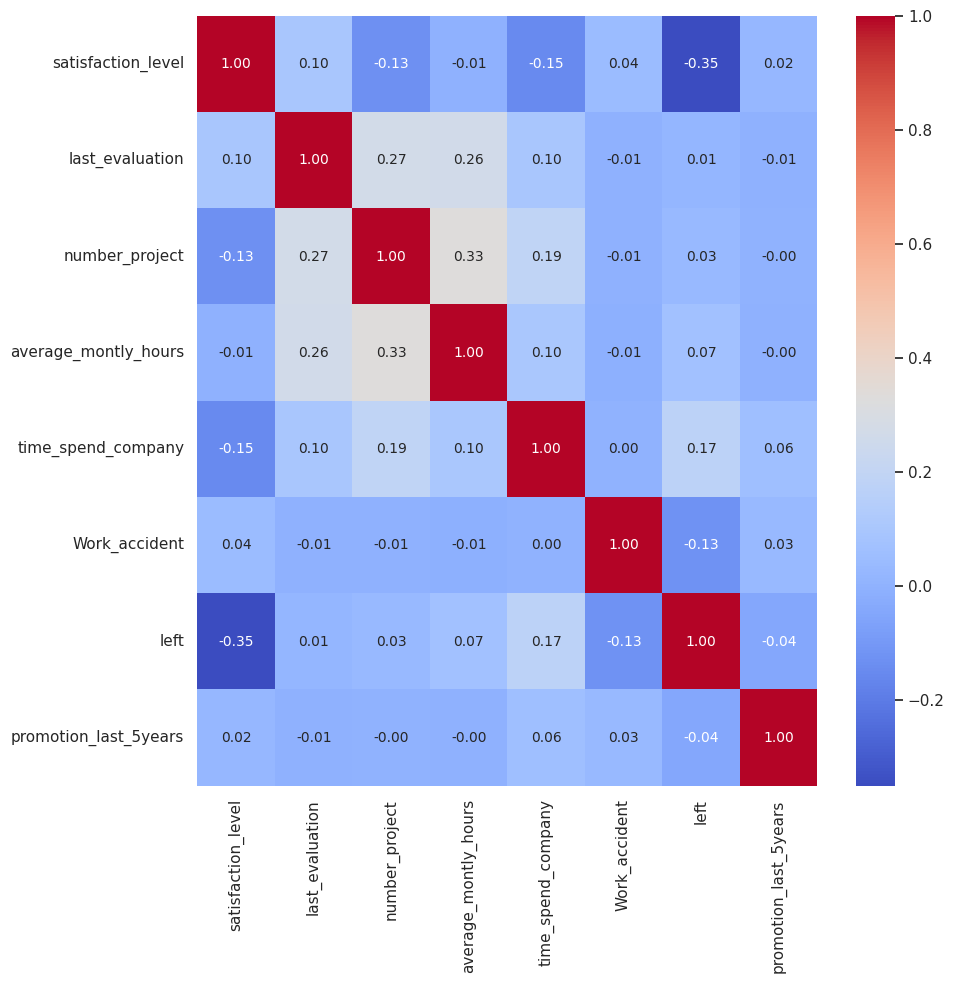

In [8]:
corr = df[col_numeric].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm',annot_kws={"size": 10},fmt=".2f")
plt.show()

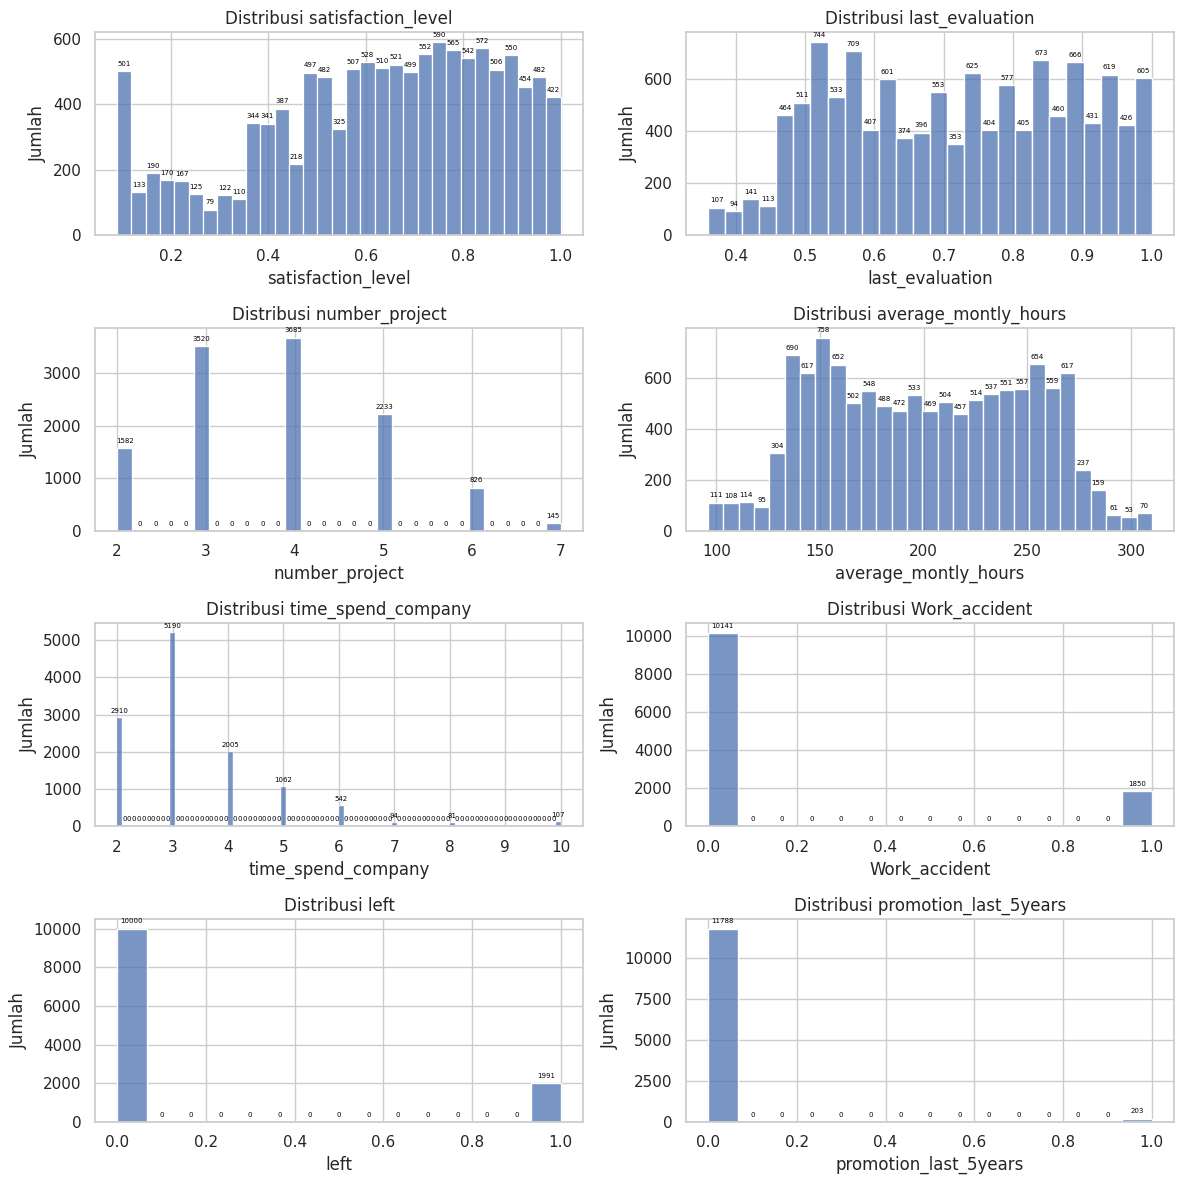

In [9]:
fig , axes = plt.subplots(4,2,figsize=(12,12))
axes_flat = axes.flatten()
n = 0
for col in col_numeric:
    sns.histplot(df[col],ax=axes_flat[n])
    axes_flat[n].bar_label(axes_flat[n].containers[0],fontsize=5,color='black',padding=3)
    axes_flat[n].set_ylabel(f'Jumlah')
    axes_flat[n].set_title(f'Distribusi {col}')
    n = n+1

fig.tight_layout()
plt.show()

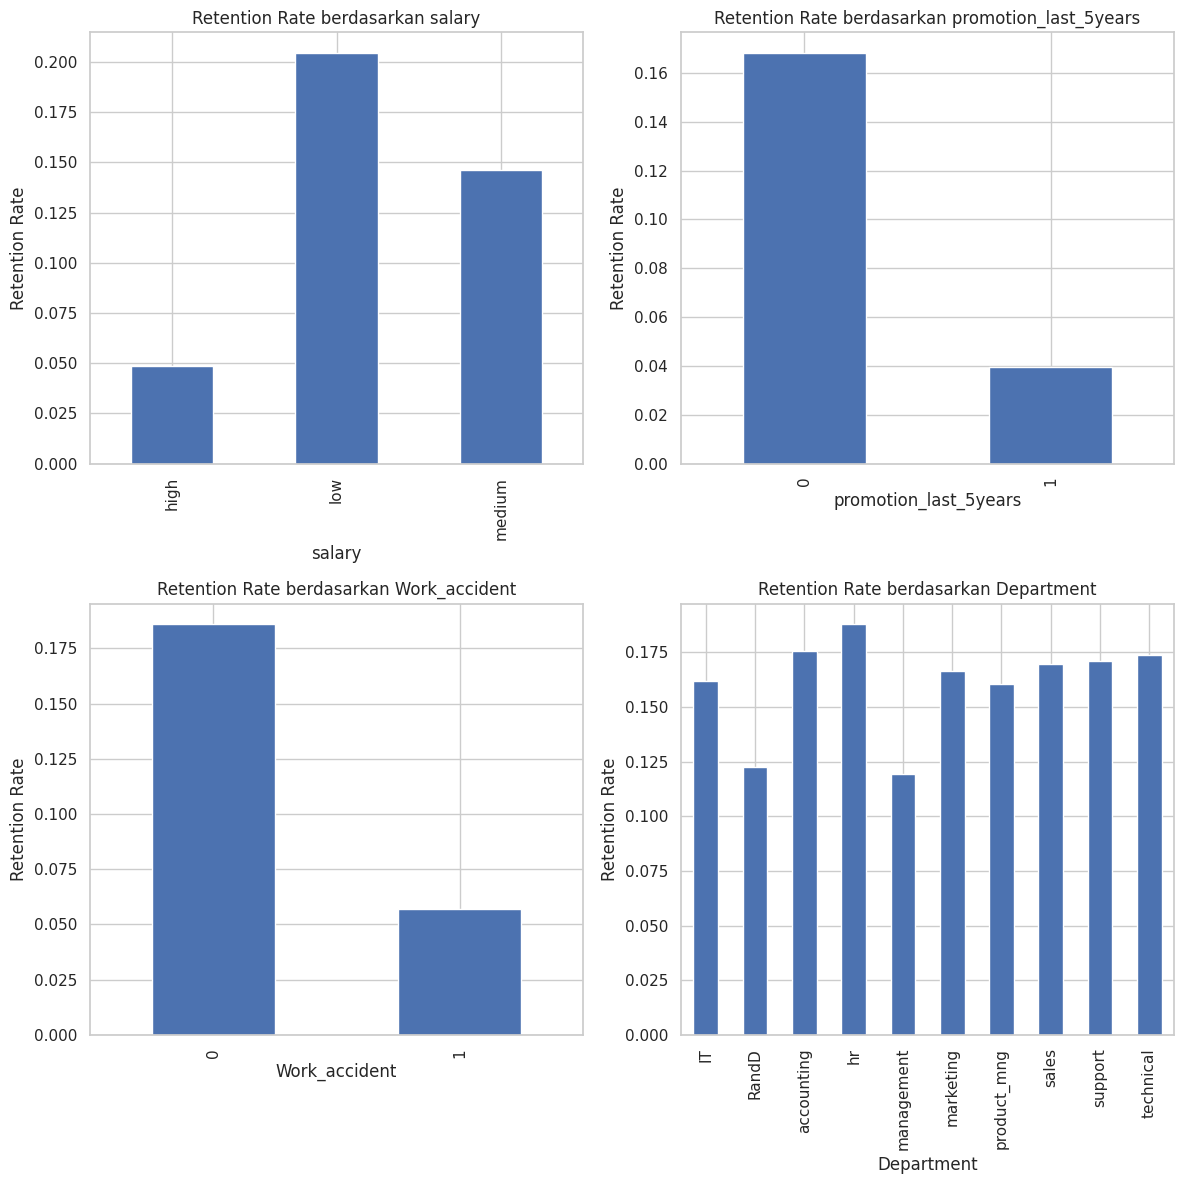

In [10]:
cols = ['salary','promotion_last_5years','Work_accident','Department']
fig, axes = plt.subplots(2,2,figsize=(12,12))
axes_flat = axes.flatten()
n = 0
for col in cols:
  retention = df.groupby(col)['left'].mean()
  retention.plot(kind='bar',ax=axes_flat[n])
  axes_flat[n].set_ylabel('Retention Rate')
  axes_flat[n].set_title(f'Retention Rate berdasarkan {col}')
  n = n+1
fig.tight_layout()
plt.show()

In [11]:
df = pd.get_dummies(df, columns=['salary'],dtype=int)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,sales,0,1,0
1,0.80,0.86,5,262,6,0,1,0,sales,0,0,1
2,0.11,0.88,7,272,4,0,1,0,sales,0,0,1
3,0.72,0.87,5,223,5,0,1,0,sales,0,1,0
4,0.37,0.52,2,159,3,0,1,0,sales,0,1,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   Department             11991 non-null  object 
 9   salary_high            11991 non-null  int64  
 10  salary_low             11991 non-null  int64  
 11  salary_medium          11991 non-null  int64  
dtypes: float64(2), int64(9), object(1)
memory usage: 1.2+ MB


In [13]:
X = df.drop(columns='left')
Y = df['left']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)
te = TargetEncoder(
    smooth=10,
    cv=5
)

X_train['Department'] = te.fit_transform(X_train[['Department']], Y_train).flatten()
X_test['Department'] = te.transform(X_test[['Department']]).flatten()

In [15]:
model = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(),
}

In [16]:
def cross_vallidation(models_dict, x, y, n_split=5):
  all_model_names = []
  all_score_means = []

  for model_name, current_model in models_dict.items():
    print(f'Model: {model_name}')
    skf = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)

    scores = cross_val_score(
        current_model,
        x,
        y,
        cv=skf.split(x, y),
        scoring='accuracy'
    )
    print(f"Akurasi: {scores}")
    print(f"Rata-rata akurasi: {scores.mean()}")
    all_model_names.append(model_name)
    all_score_means.append(scores.mean())

  metrics = pd.DataFrame({
      'Model': all_model_names,
      'Score': all_score_means
  })
  return metrics.sort_values(by='Score', ascending=False)

In [17]:
metrics = cross_vallidation(model,X_train,Y_train)
metrics

Model: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Akurasi: [0.82491894 0.84059314 0.83410565 0.8313253  0.83317887]
Rata-rata akurasi: 0.832824381932905
Model: Decision Tree
Akurasi: [0.9671144  0.97219648 0.96663577 0.96200185 0.96848934]
Rata-rata akurasi: 0.9672875704907492
Model: Random Forest
Akurasi: [0.98425197 0.98656163 0.98609824 0.97961075 0.98702502]
Rata-rata akurasi: 0.9847095225237716
Model: XGBoost
Akurasi: [0.98239926 0.98609824 0.98424467 0.98053753 0.98656163]
Rata-rata akurasi: 0.9839682669824915
Model: LightGBM
[LightGBM] [Info] Number of positive: 1435, number of negative: 7197
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 452
[LightGBM] [Info] Number of data points in the train set: 8632, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166242 -> initscore=-1.612499
[LightGBM] [

,Model,Score
4,LightGBM,0.984988
2,Random Forest,0.984710
3,XGBoost,0.983968
1,Decision Tree,0.967288
0,Logistic Regression,0.832824


In [18]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, Y_train)
print(classification_report(Y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1003
           1       0.97      0.91      0.94       197

    accuracy                           0.98      1200
   macro avg       0.98      0.95      0.96      1200
weighted avg       0.98      0.98      0.98      1200

